In [2]:
import os
import xml.etree.ElementTree as ET
from PIL import Image
import matplotlib.pyplot as plt
import random
from collections import defaultdict

# Paths
image_dir = "/Users/hebah/Downloads/VOC_project/VOC_PCB/JPEGImages"
annotation_dir = "/Users/hebah/Downloads/VOC_project/VOC_PCB/Annotations"


In [3]:

# Helper: Parse Pascal VOC .xml file
def parse_annotation(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()
    
    objects = []
    for obj in root.findall('object'):
        label = obj.find('name').text
        bbox = obj.find('bndbox')
        box = {
            'label': label,
            'xmin': int(bbox.find('xmin').text),
            'ymin': int(bbox.find('ymin').text),
            'xmax': int(bbox.find('xmax').text),
            'ymax': int(bbox.find('ymax').text)
        }
        objects.append(box)
    return objects


Plot one sample image

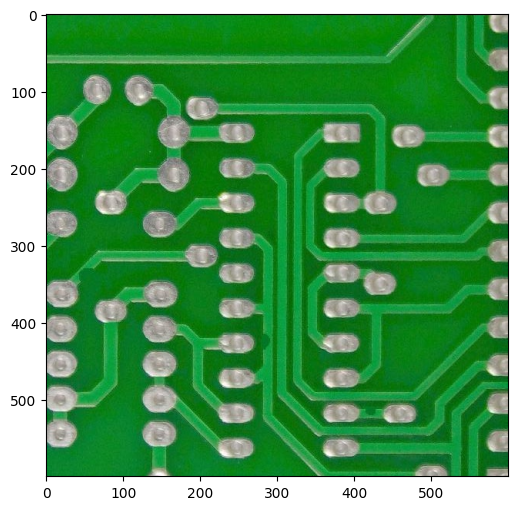

In [4]:
# List all image files
image_files = [f for f in os.listdir(image_dir) if f.endswith(".jpg")]

# Choose a random image
sample_file = random.choice(image_files)
image_path = os.path.join(image_dir, sample_file)
annotation_path = os.path.join(annotation_dir, sample_file.replace('.jpg', '.xml'))

# Open image
img = Image.open(image_path)
objects = parse_annotation(annotation_path)

# Show image + bounding boxes
plt.figure(figsize=(8, 6))
plt.imshow(img)
ax = plt.gca()

Plot sample image and draw bbox with class name (annoation)

In [5]:
# Retry until you get a safe image size
MAX_WIDTH = 5000
MAX_HEIGHT = 5000

while True:
    sample_file = random.choice(image_files)
    image_path = os.path.join(image_dir, sample_file)
    annotation_path = os.path.join(annotation_dir, sample_file.replace('.jpg', '.xml'))

    try:
        img = Image.open(image_path)
        width, height = img.size

        if width < MAX_WIDTH and height < MAX_HEIGHT:
            break  # valid image, exit loop
    except:
        continue  # skip unreadable images

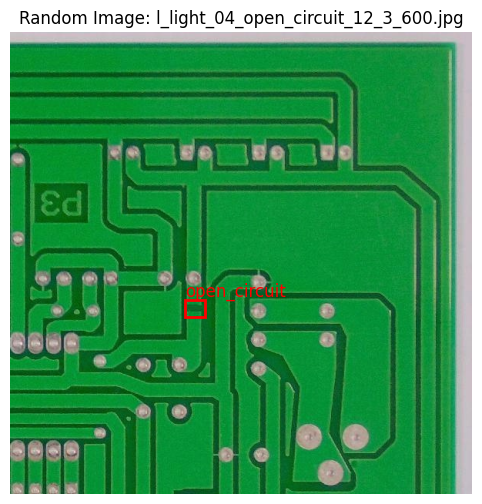

In [6]:
# Load annotation
objects = parse_annotation(annotation_path)

# Plot image
plt.figure(figsize=(8, 6))
plt.imshow(img)
ax = plt.gca()

for obj in objects:
    box = [obj['xmin'], obj['ymin'], obj['xmax'] - obj['xmin'], obj['ymax'] - obj['ymin']]
    ax.add_patch(plt.Rectangle((box[0], box[1]), box[2], box[3], 
                               fill=False, edgecolor='red', linewidth=2))
    plt.text(obj['xmin'], obj['ymin'] - 5, obj['label'], color='red', fontsize=12)

plt.title(f"Random Image: {sample_file}")
plt.axis('off')
plt.show()

Count number of classes in the dataset and nymber of images per class

In [7]:
# Dictionary to store counts
class_to_images = defaultdict(set)  # Set to avoid duplicates
all_classes = set()

# Loop over all annotation files
for filename in os.listdir(annotation_dir):
    if not filename.endswith('.xml'):
        continue

    file_path = os.path.join(annotation_dir, filename)
    tree = ET.parse(file_path)
    root = tree.getroot()

    image_id = filename.replace(".xml", "")

    for obj in root.findall('object'):
        label = obj.find('name').text.strip()
        all_classes.add(label)
        class_to_images[label].add(image_id)

# Print results
print(f"\n📦 Total number of classes: {len(all_classes)}\n")
print("📊 Number of images per class:\n")
for label, image_ids in class_to_images.items():
    print(f"- {label}: {len(image_ids)} images")


📦 Total number of classes: 6

📊 Number of images per class:

- mouse_bite: 1852 images
- spur: 1752 images
- missing_hole: 1832 images
- short: 1732 images
- open_circuit: 1740 images
- spurious_copper: 1760 images


Plot sample images and draw bbox with classes names

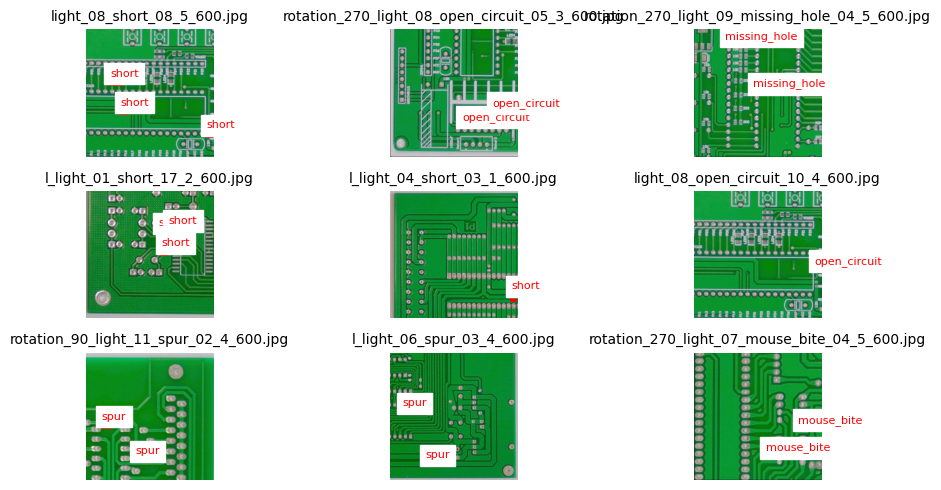

In [8]:
# === SETUP ===
n_rows, n_cols = 3, 3  # Grid size

# === PLOT GRID ===
fig, axs = plt.subplots(n_rows, n_cols, figsize=(10, 5))
axs = axs.flatten()

plotted = 0
while plotted < n_rows * n_cols:
    file = random.choice(image_files)
    img_path = os.path.join(image_dir, file)
    xml_path = os.path.join(annotation_dir, file.replace(".jpg", ".xml"))

    # Skip if no annotation
    if not os.path.exists(xml_path):
        continue

    try:
        img = Image.open(img_path)
        w, h = img.size
        if w > MAX_WIDTH or h > MAX_HEIGHT:
            continue

        objects = parse_annotation(xml_path)

        axs[plotted].imshow(img)
        axs[plotted].set_title(file, fontsize=10)
        axs[plotted].axis('off')

        for obj in objects:
            box = [obj['xmin'], obj['ymin'], obj['xmax'] - obj['xmin'], obj['ymax'] - obj['ymin']]
            axs[plotted].add_patch(
                plt.Rectangle((box[0], box[1]), box[2], box[3],
                              edgecolor='red', facecolor='none', linewidth=2)
            )
            axs[plotted].text(box[0], box[1] - 5, obj['label'],
                              color='red', fontsize=8, backgroundcolor='white')
        plotted += 1

    except Exception as e:
        print(f"Error reading {file}: {e}")
        continue

plt.tight_layout()
plt.show()